# Pairs trading: Engle–Granger cointegration with half-life filter — rolling β

Universe: crypto pairs, daily bars  
Train: 2022-01-01 → 2024-01-01 · Test: 2024-01-02 → 2026-05-22

**Following on from the static cointegration notebook**, I tested whether letting the hedge ratio change over time improves on the static result. Everything else is held identical — same pairs, same z-score window, same entry/exit thresholds, same cost model — so the only thing that changes is how β is estimated. I swept the rolling β window across **30, 60, 90, 120, 180 and 365 days**, with the static-β notebook as the baseline.

## Key findings

**Static β beats every rolling specification on every metric.** The cleanest read is the table below: net OOS Sharpe of 2.46 for static drops to between −0.12 and 1.11 for any rolling window, alpha t-stat falls from 9.7 to 2–5, and max drawdown deepens from −8.7% to as much as −50%. The longest window (365 days) gets closest to static — because at that length β barely moves — but still falls well short.

**Why this might be**:

- *Estimation noise.* A short window like 30 days gives a noisy β, and that noise gets injected directly into the spread. The strategy could maybe be trading β-estimation error rather than mispricings.
- *Higher turnover, higher costs.* Shorter windows make β move more, which moves position sizes more, which means more trading. Daily turnover triples at 30 days (32% vs 9.5% static).

**OOS still degrades sharply on the static notebook.** That part of the story doesn't change: the IS-to-OOS Sharpe drop (7.5 → 2.5) shows the static result is still flattered by selecting and fitting on the same window. This remains the same for rolling beta — the gap is about pair selection being trained on the same data.

**What this tells us about the cointegrated pairs.** Pairs that pass the EG test and half-life filter have hedge ratios stable enough that re-estimating β is potentially throwing away info rather than gaining.

## Sensitivity table — rolling β windows (net of 20 bps)

| β spec | Sharpe IS | Sharpe OOS | Sharpe FS | Return OOS | Max DD OOS | DD duration OOS | Turnover | α t-stat | IR |
|:--|--:|--:|--:|--:|--:|--:|--:|--:|--:|
| **static** | **7.55** | **2.46** | **5.14** | **39.3%** | **−8.7%** | **107** | **9.5%** | **9.74** | **4.63** |
| 30 | 2.13 | −0.12 | 1.02 | −5.1% | −49.6% | 850 | 31.8% | 1.94 | 0.37 |
| 60 | 3.65 | 0.78 | 2.13 | 28.1% | −27.2% | 142 | 21.1% | 4.26 | 1.64 |
| 90 | 4.26 | 0.29 | 1.84 | 10.1% | −51.5% | 450 | 17.2% | 3.36 | 1.27 |
| 120 | 4.25 | 0.70 | 2.28 | 20.8% | −29.9% | 375 | 15.0% | 4.43 | 1.75 |
| 180 | 5.30 | 0.55 | 2.58 | 13.6% | −25.2% | 389 | 11.5% | 4.88 | 1.90 |
| 365 | 4.87 | 1.11 | 2.83 | 21.1% | −23.5% | 288 | 8.5% | 5.40 | 2.96 |

> **Next step (separate notebook):** keep β static but make *pair selection* dynamic — re-run the EG and half-life screen every few months on a trailing window, so the pair set itself can refresh. This tests the other open question: whether the cointegrated relationships decay over time.

In [28]:
# ____ Imports and data loading ____
import pandas as pd
import numpy as np
from datetime import datetime
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
import statsmodels.api as sm
# Cointegration-specific: pair enumeration, parallel execution, Engle-Granger test
from itertools import combinations
from statsmodels.tsa.stattools import adfuller
from joblib import Parallel, delayed
from statsmodels.tsa.stattools import coint

def read_crypto_data(interval):
    """
    Load cached price and volume pickles for a given timeframe
    interval:
        One of ["1d", "8h", "4h", "1h"] matching saved files.
    """
    path_px = Path(f"data_output/crypto_px_{interval}.pkl")
    path_vol = Path(f"data_output/crypto_vol_{interval}.pkl")
    if not path_px.exists() or not path_vol.exists():
        raise FileNotFoundError(f"Missing pickle files for interval {interval}")
    crypto_px = pd.read_pickle(path_px)
    crypto_vol = pd.read_pickle(path_vol)
    return crypto_px, crypto_vol

In [29]:
# ___ Functions for key stats/turnover/sharpe ____
# Annualisation helper
PERIODS_PER_YEAR = {"1d": 365, "8h": 365*3, "4h": 365*6, "1h": 365*24}

def compute_sharpe(rets,ppy=365):
    mean = rets.mean()*ppy # Crypto trades every day
    vol = rets.std()*np.sqrt(ppy)
    sharpe = mean / vol
    return sharpe

def drawdown(rets):
    cum = (1+rets).cumprod()
    return cum/cum.cummax()  - 1

def max_dd(rets):
    return drawdown(rets).min()

def max_dd_duration(rets):
    dd = drawdown(rets)
    underwater = dd < 0
    groups = (~underwater).cumsum()
    return int(underwater.groupby(groups).cumsum().max())

def compute_keystats(rets, ppy=365):
    rets = rets.dropna()
    if len(rets) == 0:
        return pd.Series({'avg': np.nan, 'vol': np.nan, 'sharpe': np.nan, 
                          'hit_rate': np.nan, 'max_dd': np.nan, 'max_dd_duration': np.nan,
        })
    avg = rets.mean() * ppy
    vol = rets.std() * np.sqrt(ppy)
    sharpe = avg / vol if vol > 0 else np.nan
    hit_rate = (rets > 0).sum() / (rets != 0).sum() if (rets != 0).any() else np.nan
    return pd.Series({'avg': avg, 'vol': vol, 'sharpe': sharpe, 
                      'hit_rate': hit_rate, 'max_dd':max_dd(rets),'max_dd_duration':max_dd_duration(rets)})

def compute_turnover(port):
    to = (port.fillna(0)-port.shift().fillna(0)).abs().sum(1)   
    return to

In [30]:
# ____ Engle-Granger two-way cointegration test for one pair (training data) ____
def adf_for_pair(coin_i, coin_j, train_px):
    # Align both series on common non-NaN, non-zero dates
    paired = train_px[[coin_i, coin_j]].replace(0, np.nan).dropna()
    
    if len(paired) < 60:   # not enough data for a meaningful test
        return (coin_i, coin_j), (1.0, 0.0, 0.0, 1.0)
    
    Y = np.log(paired[coin_i]).values
    X = np.log(paired[coin_j]).values

    try:
        # Test both directions and keep the WORSE p-value — a pair only qualifies if ...
        # ...it's cointegrated whichever coin is the dependent one (conservative)
        # Y on X
        t_stat_1, p_value_1, _ = coint(Y, X)
        # X on Y
        t_stat_2, p_value_2, _ = coint(X, Y)
        p_value = max(p_value_1, p_value_2)
        t_stat  = max(t_stat_1, t_stat_2)
        # OLS fit kept for reference / diagnostics only — the rolling build_signals
        # recomputes alpha/beta on a rolling window and ignores these values
        model = sm.OLS(Y, sm.add_constant(X)).fit()
        alpha = model.params[0]
        beta  = model.params[1]
    except (ValueError, np.linalg.LinAlgError):
        return (coin_i, coin_j), (1.0, 0.0, 0.0, 1.0)   # fail-safe: p=1 → never selected
    return (coin_i, coin_j), (p_value, t_stat, alpha, beta)

In [31]:
# ____ Half-life of mean reversion filter ___
def compute_half_life(spread):
    """
    Compute the half-life of mean reversion for a spread series.
    Uses the OLS regression: Δz_t = -λ * z_{t-1} + ε
    Half-life = ln(2) / λ
    Returns half-life in bars (days for 1d data).
    Returns np.inf if the series isn't mean-reverting (λ <= 0).
    """
    spread = spread.dropna()
    if len(spread) < 30:
        return np.inf
    
    z_lag = spread.shift(1).dropna()   # yesterday's spread level
    dz = spread.diff().dropna()        # today's change in the spread
    # Align
    z_lag, dz = z_lag.align(dz, join='inner')
    
    if len(z_lag) < 10 or z_lag.var() == 0:
        return np.inf
    # OLS slope of dz on z_lag via cov/var; λ = -slope is the pull-back speed
    beta = np.cov(z_lag, dz, ddof=1)[0, 1] / np.var(z_lag, ddof=1)
    lambda_hat = -beta
    if lambda_hat <= 0:
        return np.inf  # not mean-reverting
    
    return np.log(2) / lambda_hat


def filter_pairs_by_half_life(pairs_df, train_px, max_half_life=30, min_half_life=2):
    """
    Filter pairs_df to keep only those with mean-reversion half-life within bounds.
    Uses the same alpha/beta from pairs_df to construct the spread.
    """
    keep_rows = []
    half_lives = []
    
    for _, row in pairs_df.iterrows():
        coin_i, coin_j = row['coin1'], row['coin2']
        alpha, beta = row['alpha'], row['beta']
        
        # Rebuild the training spread with the frozen hedge ratio
        log_i = np.log(train_px[coin_i].replace(0, np.nan).ffill())
        log_j = np.log(train_px[coin_j].replace(0, np.nan).ffill())
        spread = log_i - beta * log_j - alpha
        
        hl = compute_half_life(spread)
        half_lives.append(hl)
        
        # Keep only pairs that revert on a tradeable horizon
        if min_half_life <= hl <= max_half_life:
            keep_rows.append(row)
    
    filtered = pd.DataFrame(keep_rows).reset_index(drop=True)
    
    print(f"  Half-life filter: {len(pairs_df)} → {len(filtered)} pairs "
          f"(kept {min_half_life} ≤ HL ≤ {max_half_life} days)")
    print(f"  Half-life distribution (all): "
          f"min={min(half_lives):.1f}, median={np.median(half_lives):.1f}, "
          f"max={max([h for h in half_lives if h != np.inf], default=np.inf):.1f}, "
          f"inf={sum(1 for h in half_lives if h == np.inf)}")
    
    return filtered, half_lives

In [32]:
# ____ Full ADF using Parelllel to reduce runtime ___
def adf_full(train_px):
    coins = train_px.columns.tolist()
    pairs = list(combinations(coins,2))
    # Parallel computation of ADF test for all pairs
    adf_results = Parallel(n_jobs=-1)(
        delayed(adf_for_pair)(coin_i, coin_j, train_px) for coin_i, coin_j in pairs)
    pairs, results = zip(*adf_results)
    adf_df = pd.DataFrame(results, columns=['p_value', 'test_statistic','alpha','beta'], index=pairs)
    adf_df = adf_df.sort_values(by='test_statistic')
    return adf_df

In [33]:
# ____ Function to choose pairs of coins based on cointegration ___
def sel_coint_pairs(train_px, sig_level = 0.01, max_pairs_per_coin = 1):
    adf_df = adf_full(train_px)
    qualified_df = adf_df[adf_df['p_value']<sig_level].copy()   # significantly cointegrated only
    if qualified_df.empty:
        return pd.DataFrame(columns=['coin1', 'coin2', 'p_value', 'test_statistic'
                                    ,'alpha','beta'])
    # Sort by most negative t-stat
    qualified_df = qualified_df.sort_values(by='test_statistic')
    # Flatten the pair tuples in the index into two columns
    qualified_df['coin1'] = [pair[0] for pair in qualified_df.index]
    qualified_df['coin2'] = [pair[1] for pair in qualified_df.index]
    qualified_df = qualified_df.reset_index(drop=True)
    
    # Keep each pair only if neither coin has hit its usage cap yet
    # (greedy from strongest down → stops one coin dominating the book)
    used = Counter()
    keep = []
    for _, row in qualified_df.iterrows():
        if used[row.coin1] < max_pairs_per_coin and used[row.coin2] < max_pairs_per_coin:
            keep.append(row)
            used[row.coin1] += 1
            used[row.coin2] += 1          
    pairs_df = pd.DataFrame(keep).reset_index(drop=True)
    pairs_df = pairs_df[['coin1', 'coin2', 'p_value', 'test_statistic','alpha','beta']]
    return pairs_df

In [34]:
# ___ Signal construction with ROLLING alpha/beta (spread → z-score) ___
def build_signals(px, pairs_df, window=180, beta_window=360):
    """
    Build z-scores using time-varying alpha/beta (rolling cov/var of log prices).
    Pair set is taken from pairs_df (static EG + HL selection); only the hedge
    ratio is now dynamic.
    window      : rolling window for the z-score (mean/std of the spread)
    beta_window : rolling window for alpha/beta
    """
    key_params = {}
    for _, row in pairs_df.iterrows():
        asset_i = row['coin1']
        asset_j = row['coin2']
        pair = (asset_i, asset_j)

        log_i = np.log(px[asset_i].replace(0, np.nan).ffill())
        log_j = np.log(px[asset_j].replace(0, np.nan).ffill())

        # Rolling OLS of log_i on log_j: beta_t = cov / var_j over beta_window
        # (same regression direction as adf_for_pair at selection time)
        roll_cov   = log_i.rolling(beta_window, min_periods=beta_window // 2).cov(log_j)
        roll_var_j = log_j.rolling(beta_window, min_periods=beta_window // 2).var()
        beta  = roll_cov / roll_var_j
        alpha = (log_i.rolling(beta_window, min_periods=beta_window // 2).mean()
                 - beta * log_j.rolling(beta_window, min_periods=beta_window // 2).mean())

        # Spread is now path-dependent through time-varying alpha_t, beta_t
        resid      = log_i - beta * log_j - alpha
        resid_mean = resid.rolling(window, min_periods=window // 2).mean()
        resid_std  = resid.rolling(window, min_periods=window // 2).std()
        z_score    = (resid - resid_mean) / resid_std

        key_params[(pair, 'beta')]    = beta
        key_params[(pair, 'alpha')]   = alpha
        key_params[(pair, 'resid')]   = resid
        key_params[(pair, 'z_score')] = z_score

    return pd.DataFrame(key_params)

In [35]:
# ____ Position sizing (z-score → weights) ____
def build_weights(key_params, pairs_df, z_entry = 2.5, z_exit = 0.5):
    """ Convert the pair-level z-scores into per-coin portfolio weights. 
    Then normalise so absolute sum of weights equal to 1"""
    pairs = list(zip(pairs_df['coin1'], pairs_df['coin2']))
    coins = sorted({c for pair in pairs for c in pair})
    raw = pd.DataFrame(index=key_params.index, columns=coins, dtype=float)
    for pair in pairs:
        asset_i, asset_j = pair
        z = key_params[(pair, 'z_score')]
        beta = key_params[(pair, 'beta')]

        # Entries
        raw.loc[z > z_entry,  asset_i] = -1
        raw.loc[z > z_entry,  asset_j] = beta
        raw.loc[z < -z_entry, asset_i] = 1
        raw.loc[z < -z_entry, asset_j] = -beta
        # Exits override entries when |z| is small
        flat = z.abs() < z_exit
        raw.loc[flat, asset_i] = 0
        raw.loc[flat, asset_j] = 0

    # Hold previous position between entry and exit thresholds
    raw = raw.ffill()
    # Normalise per bar so |weights|.sum = 1 (or 0 if all flat)
    pos = raw.divide(raw.abs().sum(axis=1),axis=0).fillna(0)

    return pos

In [36]:
# ___ Backtest formula ____
def backtest(px, pos):
    simple_ret = px.pct_change(fill_method = None)
    cols = [c for c in pos.columns if c in simple_ret.columns]
    port_ret = (pos[cols].shift(1) * simple_ret[cols]).sum(axis=1) # Avoid lookahead bias
    return port_ret

In [37]:
# ____ Main run and stats for different sample periods ____
def run_strategy(px, pairs_df,  window=180, z_entry=2.5, z_exit=0.5,beta_window=180):
    """
    Run the full pipeline on a price series and return strategy returns.
    Rolling beta/alpha computed on `beta_window`; z-score on `window`.
    """
    signals = build_signals(px, pairs_df, window=window,beta_window=beta_window)
    weights = build_weights(signals, pairs_df,
                            z_entry=z_entry, z_exit=z_exit)
    port_ret = backtest(px, weights)
    return port_ret, weights, signals

def split_stats(port_ret, split_date, ppy=365):
    """
    Compute key stats for in-sample, out-of-sample, and full-sample periods.
    split_date: first date of the out-of-sample period.
    """
    in_sample = port_ret.loc[:split_date].iloc[:-1]   # exclude split_date itself
    out_sample = port_ret.loc[split_date:]
    full_sample = port_ret

    stats = pd.DataFrame({
        'in_sample': compute_keystats(in_sample, ppy=ppy),
        'out_sample': compute_keystats(out_sample, ppy=ppy),
        'full_sample': compute_keystats(full_sample, ppy=ppy),
    })
    return stats

In [ ]:
split_date = "2024-01-02"
split_ts = pd.to_datetime(split_date)
crypto_px, crypto_vol = read_crypto_data("1d")
train_px = crypto_px.loc[:"2024-01-01"].copy()
coverage = train_px.notna().mean()
eligible = coverage[
    coverage >= 0.90
].index
crypto_px = crypto_px[eligible]
crypto_vol = crypto_vol[eligible]
train_px = train_px[eligible]

# 1. Cointegration pair selection on training data
pairs_df = sel_coint_pairs(train_px, sig_level=0.01, max_pairs_per_coin=1)
print(f"After EG cointegration: {len(pairs_df)} pairs")

# 2. Half-life filter
pairs_df, half_lives = filter_pairs_by_half_life(
    pairs_df, train_px, max_half_life=20, min_half_life=4)
print(f"After half-life filter: {len(pairs_df)} pairs")

# 3. Run strategy on FULL price series 
port_ret, weights, signals = run_strategy(
    crypto_px, pairs_df, window=180, z_entry=2.5, z_exit=0.5,beta_window=360)

# 4. Get stats by period
stats = split_stats(port_ret, split_date=split_date, ppy=365)
btc_ret = crypto_px['BTC/USDT'].pct_change(fill_method=None)
btc_full = compute_keystats(btc_ret, ppy=365).rename('btc_hodl')
combined = pd.concat([stats, btc_full], axis=1)
print("\nStats by sample (gross of fees):")
print(combined)

# 5. Plot equity curve with split marker
equity = (1 + port_ret).cumprod()
btc_equity = (1 + btc_ret).cumprod()
ax = equity.plot(figsize=(10, 4), label='Pair-trading strategy')
btc_equity.plot(ax=ax, label='BTC buy-and-hold', alpha=0.7)
ax.axvline(pd.to_datetime(split_date), color='red', linestyle='--', label='train/test split')
ax.set_title("Strategy vs BTC buy-and-hold - Gross")
ax.legend()
plt.show()

In [ ]:
# ____ Net returns (based on 20bps) + stats ____
tcost_bps = 20  # 20 bps for market orders (commissions + slippage)
to = compute_turnover(weights)
turnover = to.mean()
holding_period = 2/turnover
port_ret_net = port_ret.subtract(to * tcost_bps * 1e-4, fill_value=0)
print(f"Turnover is {turnover}")
print(f"Corresponding holding period is {holding_period}")
# ---------- Stats ----------
stats_net = split_stats(port_ret_net, split_date=split_date, ppy=365)
btc_full = compute_keystats(btc_ret, ppy=365).rename('btc_hodl')
combined_net = pd.concat([stats_net, btc_full], axis=1)
print(f"\nStats by sample (net of {tcost_bps}bps):")
print(combined_net)

equity_net = (1 + port_ret_net).cumprod()
btc_equity = (1 + btc_ret).cumprod()
ax = equity_net.plot(figsize=(10, 4), label='Pair-trading strategy (net)')
btc_equity.plot(ax=ax, label='BTC buy-and-hold', alpha=0.7)
ax.axvline(pd.to_datetime(split_date), color='red', linestyle='--', label='train/test split')
ax.set_title(f"Strategy vs BTC buy-and-hold - Net of {tcost_bps}bps")
ax.legend()
plt.show()

In [ ]:
# ____ BM-adjusted performance vs BTC ___
def alpha_beta_block(strat_ret, btc_ret, label, ppy=365, roll_window=365, hac_lags=5):
    """Compute beta, alpha, alpha t-stat, IR"""
    df = pd.concat([strat_ret.rename('strat'), btc_ret.rename('btc')], axis=1).dropna()

    # Rolling PIT beta + residuals
    corr = df['strat'].rolling(roll_window).corr(df['btc'])
    vol_s = df['strat'].rolling(roll_window).std()
    vol_b = df['btc'].rolling(roll_window).std()
    beta_roll = corr * vol_s / vol_b
    resid = df['strat'] - beta_roll * df['btc']
    ir = resid.mean() / resid.std() * np.sqrt(ppy) if resid.std() > 0 else np.nan

    # Full-sample OLS for alpha + t-stat
    X = sm.add_constant(df['btc'])
    model = sm.OLS(df['strat'], X).fit(cov_type='HAC', cov_kwds={'maxlags': hac_lags})
    alpha_ann   = model.params['const'] * ppy
    beta_full   = model.params['btc']
    alpha_tstat = model.tvalues['const']
    stats = pd.Series({'beta_OLM': beta_full, 'alpha_ann':   alpha_ann, 'alpha_tstat': alpha_tstat,
        'ir':ir,}, name=label)
    return stats, resid

# Apply to gross and net
gross_ab, gross_resid = alpha_beta_block(port_ret, btc_ret, 'gross')
net_ab, net_resid   = alpha_beta_block(port_ret_net, btc_ret, 'net')

ab_table = pd.concat([gross_ab, net_ab], axis=1)
print("\nAlpha/Beta/IR vs BTC:")
print(ab_table)

corr_df = pd.concat([
    net_resid.rename('resid_net'),
    btc_ret.rename('btc'),
], axis=1).dropna()
print("Correlation of resids with BTC matrix:")
print(corr_df.corr().round(3))

In [39]:
# ===== Rolling β sensitivity sweep (net of 20 bps) =====
# Re-runs the strategy at several β-window lengths, holding every other parameter
# identical to the main run. Static β baseline included as the first row.
Z_WINDOW=180
def build_signals_static(px, pairs_df, window=180):
    """Static α/β from pairs_df — matches the static cointegration notebook."""
    key_params = {}
    for _, row in pairs_df.iterrows():
        asset_i, asset_j = row['coin1'], row['coin2']
        alpha, beta = row['alpha'], row['beta']
        pair = (asset_i, asset_j)
        log_i = np.log(px[asset_i].replace(0, np.nan).ffill())
        log_j = np.log(px[asset_j].replace(0, np.nan).ffill())
        resid = log_i - beta * log_j - alpha
        resid_mean = resid.rolling(window, min_periods=window // 2).mean()
        resid_std  = resid.rolling(window, min_periods=window // 2).std()
        z_score    = (resid - resid_mean) / resid_std
        key_params[(pair, 'beta')]    = pd.Series(beta, index=px.index)
        key_params[(pair, 'alpha')]   = pd.Series(alpha, index=px.index)
        key_params[(pair, 'resid')]   = resid
        key_params[(pair, 'z_score')] = z_score
    return pd.DataFrame(key_params)


def run_for_beta_spec(beta_spec):
    """beta_spec: 'static' or an integer rolling window."""
    if beta_spec == 'static':
        signals = build_signals_static(crypto_px, pairs_df, window=Z_WINDOW)
    else:
        signals = build_signals(crypto_px, pairs_df,
                                window=Z_WINDOW, beta_window=beta_spec)
    weights  = build_weights(signals, pairs_df, z_entry=2.5, z_exit=0.5)
    port_ret = backtest(crypto_px, weights)
    return port_ret, weights


specs = ['static', 30, 60, 90, 120, 180, 365]
sweep_rows = []

for spec in specs:
    print(f"Running beta = {spec}...")
    pr, w = run_for_beta_spec(spec)

    # Flat 20 bps net
    to_series = compute_turnover(w)
    pr_net    = pr.subtract(to_series * 20 * 1e-4, fill_value=0)

    stats  = split_stats(pr_net, split_date=split_date, ppy=365)
    ab, _  = alpha_beta_block(pr_net, btc_ret, 'net')

    sweep_rows.append({
        'beta_window':  spec,
        'sharpe_IS':    stats.loc['sharpe',          'in_sample'],
        'sharpe_OOS':   stats.loc['sharpe',          'out_sample'],
        'sharpe_FS':    stats.loc['sharpe',          'full_sample'],
        'return_OOS':   stats.loc['avg',             'out_sample'],
        'maxDD_OOS':    stats.loc['max_dd',          'out_sample'],
        'DDdur_OOS':    stats.loc['max_dd_duration', 'out_sample'],
        'turnover':     to_series.mean(),
        'alpha_tstat':  ab['alpha_tstat'],
        'IR':           ab['ir'],
    })

sweep_df = pd.DataFrame(sweep_rows).set_index('beta_window')
print("\n=== Rolling β sensitivity (net of 20 bps) ===")
print(sweep_df.round(3))

Running beta = static...
Running beta = 30...
Running beta = 60...
Running beta = 90...
Running beta = 120...
Running beta = 180...
Running beta = 365...

=== Rolling β sensitivity (net of 20 bps) ===
             sharpe_IS  sharpe_OOS  sharpe_FS  return_OOS  maxDD_OOS  \
beta_window                                                            
static           7.545       2.463      5.145       0.393     -0.087   
30               2.134      -0.124      1.016      -0.051     -0.496   
60               3.649       0.779      2.130       0.281     -0.272   
90               4.256       0.287      1.842       0.101     -0.515   
120              4.251       0.704      2.276       0.208     -0.299   
180              5.300       0.551      2.578       0.136     -0.252   
365              4.865       1.109      2.832       0.211     -0.235   

             DDdur_OOS  turnover  alpha_tstat     IR  
beta_window                                           
static           107.0     0.095        

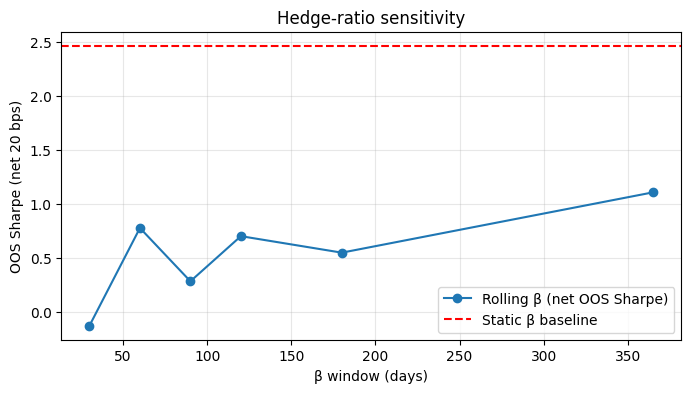

In [40]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 4))
rolling = sweep_df.drop('static')
ax.plot(rolling.index.astype(int), rolling['sharpe_OOS'], 'o-', label='Rolling β (net OOS Sharpe)')
ax.axhline(sweep_df.loc['static', 'sharpe_OOS'], color='red', linestyle='--', label='Static β baseline')
ax.set_xlabel('β window (days)'); ax.set_ylabel('OOS Sharpe (net 20 bps)')
ax.set_title('Hedge-ratio sensitivity'); ax.legend(); ax.grid(alpha=0.3)
plt.show()

In [ ]:
# ___ Drawdown: Strategy (net) vs BTC buy-and-hold ___
comb_ret = pd.concat([
    port_ret_net.rename('strat_ret'),
    btc_ret.rename('buy_and_hold_btc'),
], axis=1).dropna()

dd = drawdown(comb_ret) * 100

plt.figure(figsize=(10, 3))
dd.plot(ax=plt.gca())
plt.axhline(0, color='black', linewidth=0.5)
plt.title('Drawdown - Strategy (net) vs BTC buy-and-hold')
plt.xlabel('Date')
plt.ylabel('Drawdown (%)')
plt.legend(['Strategy (net)', 'BTC buy-and-hold'])
plt.show()
print(f"Max drawdown - Strategy (net):   {dd['strat_ret'].min():.2f}%")
print(f"Max drawdown - BTC buy-and-hold: {dd['buy_and_hold_btc'].min():.2f}%")

In [ ]:
# ___ Drawdown duration: Strategy (net) vs BTC buy-and-hold ___
def drawdown_duration(rets):
    dd = drawdown(rets)
    underwater = dd < 0
    groups = (~underwater).cumsum()
    return underwater.groupby(groups).cumsum()

ddd = comb_ret.apply(drawdown_duration)

plt.figure(figsize=(10, 3))
ddd.plot(ax=plt.gca())
plt.title('Drawdown duration - Strategy (net) vs BTC buy-and-hold')
plt.xlabel('Date')
plt.ylabel('Days underwater')
plt.legend(['Strategy (net)', 'BTC buy-and-hold'])
plt.show()

print(f"Max drawdown duration - Strategy (net):   {int(ddd['strat_ret'].max())} days")
print(f"Max drawdown duration - BTC buy-and-hold: {int(ddd['buy_and_hold_btc'].max())} days")

In [ ]:
# Gross exposure should be ~1.0 every day (or 0 when fully flat)
gross = weights.abs().sum(axis=1)
print("\nGross exposure stats:")
print(gross.describe())
print(f"\nDays with gross == 0 (fully flat): {(gross == 0).sum()}")
print(f"Days with gross ~= 1: {((gross > 0.99) & (gross < 1.01)).sum()}")
print(f"\nGross exposure around split:")
print(gross.loc[split_ts - pd.Timedelta(days=2):split_ts + pd.Timedelta(days=2)])

In [ ]:
# ____ Net returns — liquidity-aware cost model ___
def compute_liquidity_aware_costs(weights, crypto_px, crypto_vol,
                                   high_liquidity_threshold_usd=10_000_000,
                                   slow_bps=7, fast_bps=20,
                                   rolling_days=30):
    w = weights.fillna(0)
    pos_change = (w - w.shift().fillna(0)).abs()
    dollar_vol = crypto_px * crypto_vol
    rolling_dvol = dollar_vol.rolling(rolling_days, min_periods=5).mean()
    common_cols = [c for c in pos_change.columns if c in rolling_dvol.columns]
    pos_change = pos_change[common_cols]
    rolling_dvol = rolling_dvol[common_cols].reindex(pos_change.index)
    bps = pd.DataFrame(
        np.where(rolling_dvol >= high_liquidity_threshold_usd, slow_bps, fast_bps),
        index=pos_change.index, columns=pos_change.columns,
    )
    daily_costs = (pos_change * bps * 1e-4).sum(axis=1).fillna(0)
    return daily_costs

In [ ]:
# ____ Net returns (with liquidity aware) + stats ____
daily_costs = compute_liquidity_aware_costs(weights, crypto_px, crypto_vol)
to = compute_turnover(weights)
turnover = to.mean()
holding_period = 2/turnover
port_ret_net = port_ret.subtract(daily_costs, fill_value=0)
print(f"Turnover is {turnover}")
print(f"Corresponding holding period is {holding_period}")

# ---------- Stats ----------
stats_net = split_stats(port_ret_net, split_date=split_date, ppy=365)
btc_full = compute_keystats(btc_ret, ppy=365).rename('btc_hodl')
combined_net = pd.concat([stats_net, btc_full], axis=1)
print(f"\nStats by sample (net of fees):")
print(combined_net)

perf_net = (1 + port_ret_net).cumprod()
btc_perf = (1 + btc_ret).cumprod()
ax = perf_net.plot(figsize=(10, 4), label='Pair-trading strategy (net)')
btc_perf.plot(ax=ax, label='BTC buy-and-hold', alpha=0.7)
ax.axvline(pd.to_datetime(split_date), color='red', linestyle='--', label='train/test split')
ax.set_title(f"Strategy vs BTC buy-and-hold - Net of fees")
ax.legend()
plt.show()